# XGBoost Return Forecasting — All 3 Models

Trains and evaluates three XGBoost models that forecast each coin's **7-day-ahead price** on the test set. Each model is trained independently per coin (8 coins total). Forecasts are evaluated at each 7-day rebalance step and outputs are consumed by CMVO for portfolio optimisation.

---

## Models

### Model 1 — XGBoost Base
- **Features:** 14 lagged close prices
- **Target:** Close price 7 days ahead (direct price prediction)
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (`n_estimators=300`, `max_depth=6`, `lr=0.05`)
- **Output:** `xgboost_forecasts.csv`, RMSE1_normalized.csv`

### Model 2 — XGBoost Features
- **Features:** 14 lagged log returns + 30/60-day rolling volatility (lagged)
- **Target:** Log return 7 days ahead â†’ converted back to price
- **Split:** 80/20 train/test
- **Hyperparameters:** Fixed (same as Base)
- **Output:** `xgb_feature_forecasts.csv`, `xgb_feature_rmses.csv`

### Model 3 — XGBoost Bayesian Optimised (BO)
- **Features:** 14 lagged close prices + 7-day rolling volatility
- **Target:** Close price 7 days ahead
- **Split:** 60/20/20 train/val/test
- **Hyperparameters:** Tuned with Optuna (30 trials, minimising val RMSE)
- **Output:** `xgboost_forecasts_BO_price_vol.csv`, `xgboost_rmse_summary_BO_price_vol.csv`

---

**Note:** Output CSVs are saved to the notebook's working directory. Tiny-price coins (median < 0.01) are log-transformed before training and inverse-transformed for evaluation.

In [1]:
import os
print(os.listdir("klines csv data/prices_cleaned"))

['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']


## Model 1 — XGBoost Base


Training: ADAUSDT
ADAUSDT RMSE: 0.160889
ADAUSDT Mean Actual Price: 0.528646
ADAUSDT NRMSE (% of mean price): 0.3043%


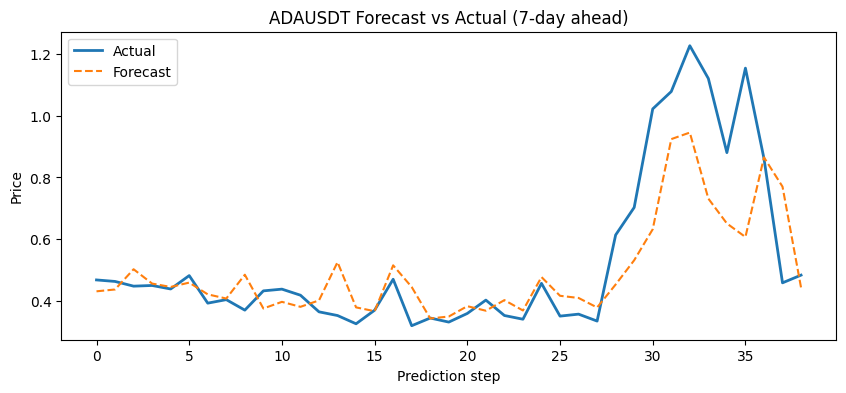


Training: BCHUSDT
BCHUSDT RMSE: 88.484263
BCHUSDT Mean Actual Price: 367.982051
BCHUSDT NRMSE (% of mean price): 0.2405%


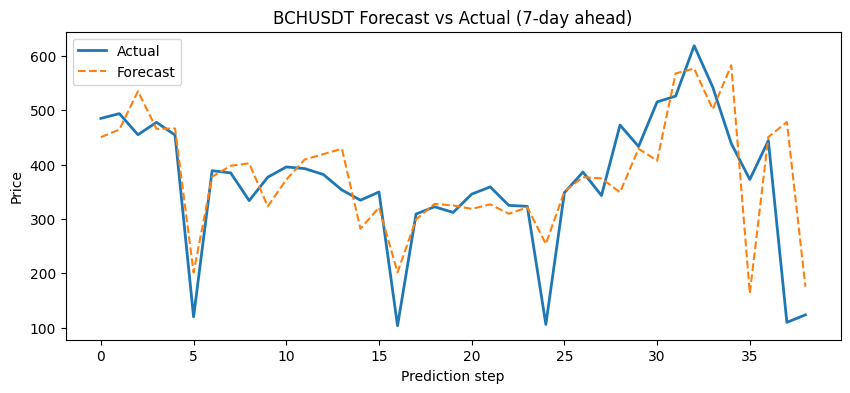


Training: BNBUSDT
BNBUSDT RMSE: 91.077701
BNBUSDT Mean Actual Price: 545.711282
BNBUSDT NRMSE (% of mean price): 0.1669%


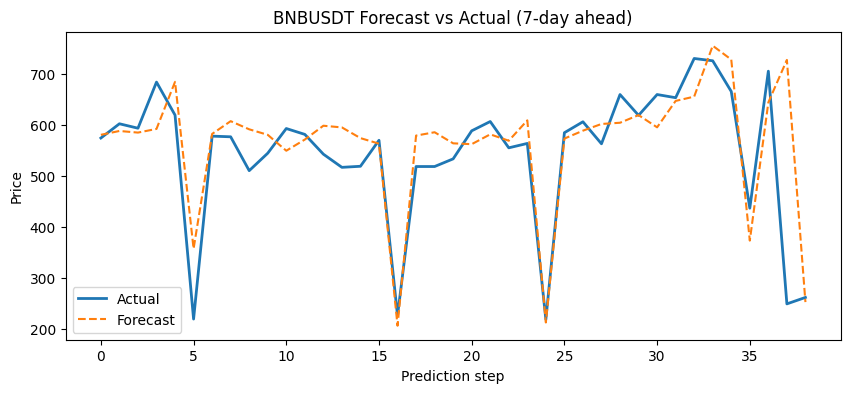


Training: BTCUSDT
BTCUSDT RMSE: 14863.288045
BTCUSDT Mean Actual Price: 64286.045128
BTCUSDT NRMSE (% of mean price): 0.2312%


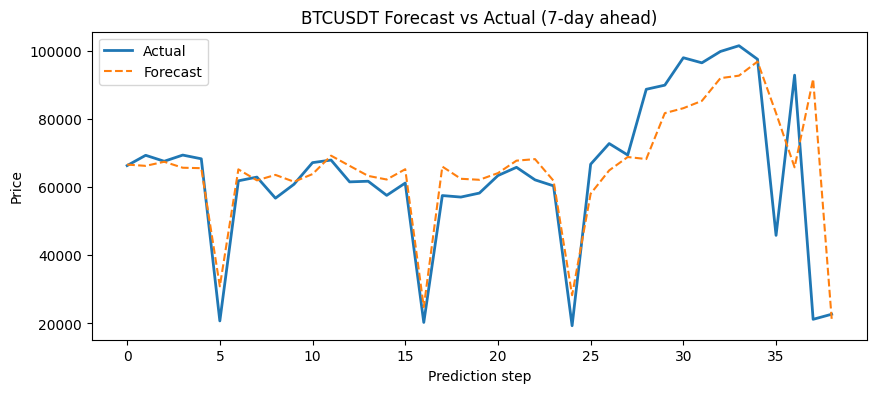


Training: ETHUSDT
ETHUSDT RMSE: 543.011128
ETHUSDT Mean Actual Price: 2851.582564
ETHUSDT NRMSE (% of mean price): 0.1904%


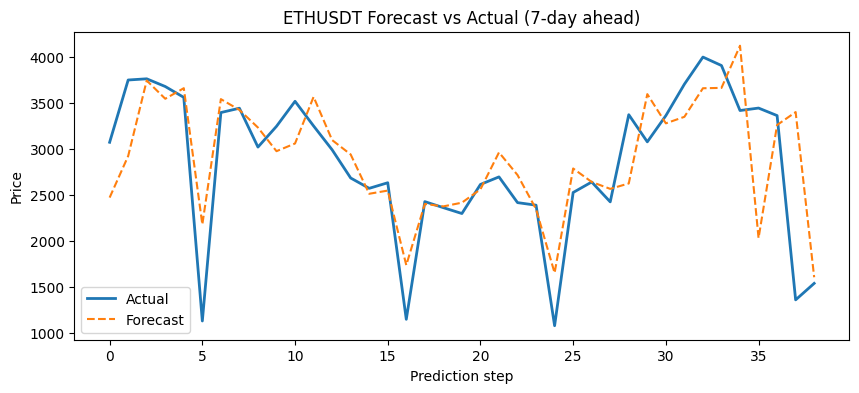


Training: SOLUSDT
SOLUSDT RMSE: 32.606461
SOLUSDT Mean Actual Price: 152.974615
SOLUSDT NRMSE (% of mean price): 0.2131%


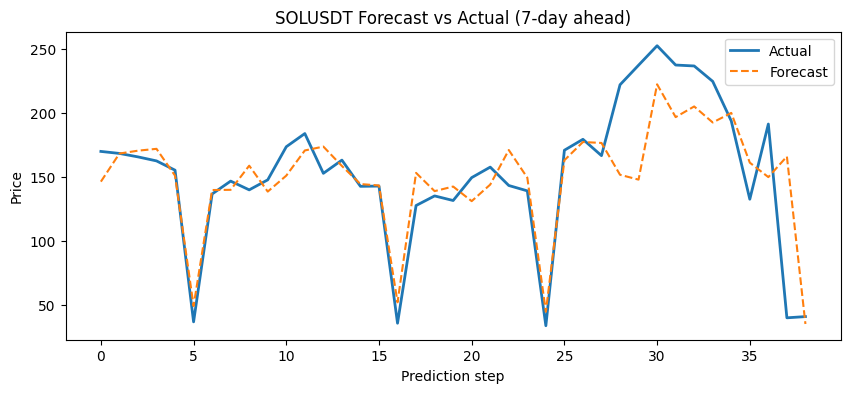


Training: TRXUSDT
TRXUSDT RMSE: 0.056930
TRXUSDT Mean Actual Price: 0.147867
TRXUSDT NRMSE (% of mean price): 0.3850%


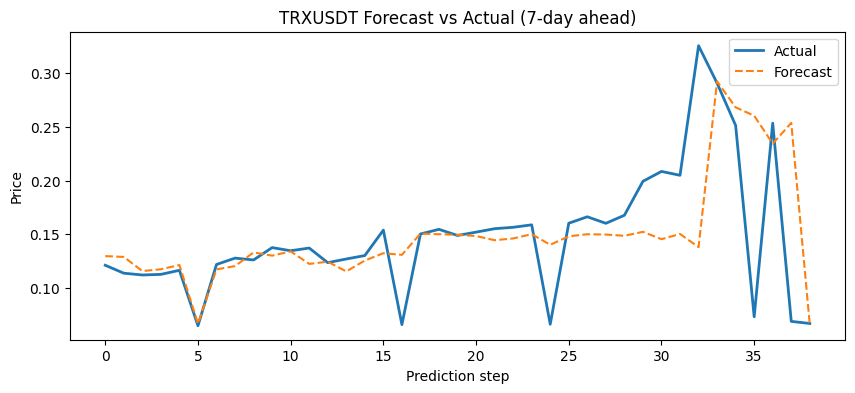


Training: XRPUSDT
XRPUSDT RMSE: 0.490586
XRPUSDT Mean Actual Price: 0.774849
XRPUSDT NRMSE (% of mean price): 0.6331%


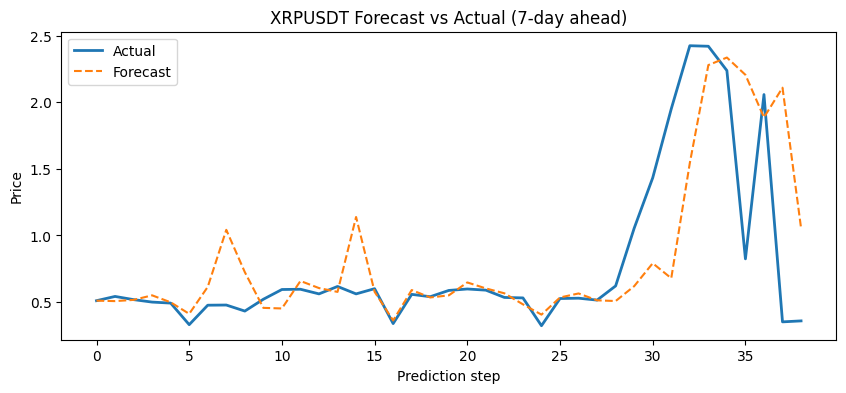

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4672,0.430223,-0.017083
1,ADAUSDT,0.4623,0.436188,-0.066378
2,ADAUSDT,0.4470,0.501902,0.085664
3,ADAUSDT,0.4492,0.455375,0.018736
4,ADAUSDT,0.4378,0.444392,-0.010702
...,...,...,...,...
307,XRPUSDT,2.2390,2.336861,-0.035033
308,XRPUSDT,0.8240,2.206910,-0.014332
309,XRPUSDT,2.0587,1.886836,1.289849
310,XRPUSDT,0.3505,2.110292,0.025060



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Mean,NRMSE_Percent
BNBUSDT,91.077701,545.711282,0.166897,0.166897
ETHUSDT,543.011128,2851.582564,0.190424,0.190424
SOLUSDT,32.606461,152.974615,0.213149,0.213149
BTCUSDT,14863.288045,64286.045128,0.231206,0.231206
BCHUSDT,88.484263,367.982051,0.240458,0.240458
ADAUSDT,0.160889,0.528646,0.304341,0.304341
TRXUSDT,0.056930,0.147867,0.385008,0.385008
XRPUSDT,0.490586,0.774849,0.633138,0.633138


In [2]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error

#lags to be 2xhorizon, so 2x30 because 30 minutes
data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

#table of lags
def create_lags(df, n_lags):
    for i in range(1, n_lags + 1):
        df[f"lag_{i}"] = df["close"].shift(i)
    return df

#total files
files = os.listdir(data_folder)

#looping through coins
for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index","close","time"]

    # ensure numeric just in case
    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    # ensuring chronological order, just in case
    df = df.sort_values("time")

    df = df[["close"]]


    # Handle tiny-price coins

    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    df["target"] = df["close"].shift(-HORIZON)

    df = create_lags(df, N_LAGS)

    df = df.dropna().reset_index(drop=True)

    #train test split
    X = df.drop(columns=["target"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]

    # Model
    model = xgb.XGBRegressor(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )

    model.fit(X_train, y_train)

    #predict
    preds = []
    actual = []
    current_prices = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]
        current_price_raw = X_test.iloc[i]['close']

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
            current_prices.append(np.exp(current_price_raw))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])
            current_prices.append(current_price_raw)

    preds = np.array(preds)
    actual = np.array(actual)
    current_prices = np.array(current_prices)

    # raw RMSE
    rmse = np.sqrt(mean_squared_error(actual, preds))

    # normalize by mean actual price
    mean_actual_price = actual.mean()
    nrmse_mean = rmse / mean_actual_price
    nrmse_pct = nrmse_mean

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Mean": nrmse_mean,
        "NRMSE_Percent": nrmse_pct
    }

    print(f"{coin} RMSE: {rmse:.6f}")
    print(f"{coin} Mean Actual Price: {mean_actual_price:.6f}")
    print(f"{coin} NRMSE (% of mean price): {nrmse_pct:.4f}%")

    # returns_predicted = (forecast - current_price) / current_price
    # gives a true forward-looking expected return signal for CMVO
    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (preds - current_prices) / current_prices
    })

    all_tables.append(table)

    # Plot
    plt.figure(figsize=(10,4))
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.show()

#final table
final_table = pd.concat(all_tables, ignore_index=True)

display(final_table)

# save predictions
final_table.to_csv("12 XGB results/xgboost_forecasts.csv", index=False)

#rmse summary
rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("NRMSE_Percent")

rmse_table.to_csv("12 XGB results/RMSE1_normalized.csv", index=True)

print("\nRMSE Summary")
display(rmse_table)


In [3]:
np.save("Results New/XGBoost Base Forecast new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/RMSE1_normalized.npy", rmse_table.values)
print("Saved .npy files for Model 1 (Base)")

Saved .npy files for Model 1 (Base)


## Model 2 — XGBoost Features

c:\Users\ameli\Documents\all ur code projects\optimising-dynamic-crypto-portfolio\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Files detected: 8
['ADAUSDT', 'BCHUSDT', 'BNBUSDT', 'BTCUSDT', 'ETHUSDT', 'SOLUSDT', 'TRXUSDT', 'XRPUSDT']

Training: ADAUSDT
ADAUSDT RMSE: 0.23214559937900137


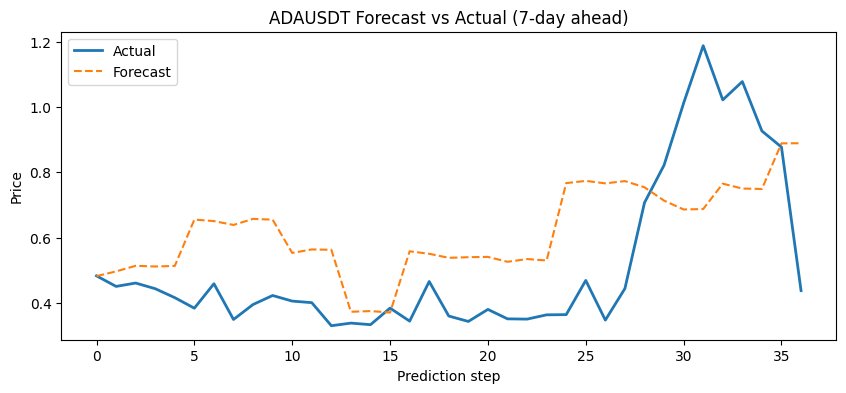


Training: BCHUSDT
BCHUSDT RMSE: 197.0139674373993


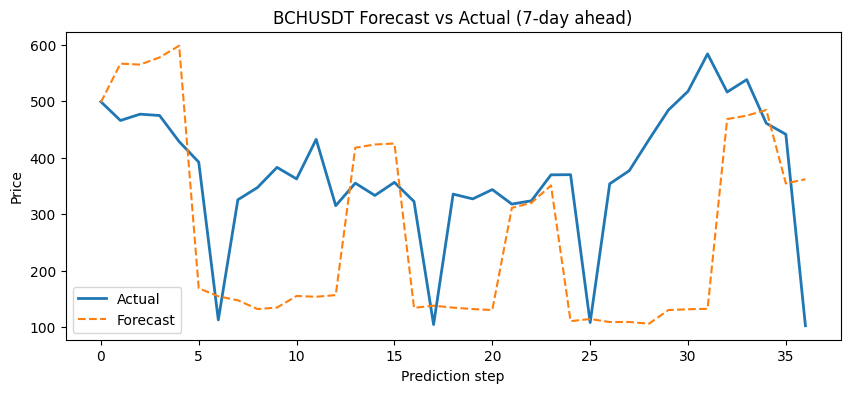


Training: BNBUSDT
BNBUSDT RMSE: 285.7360054027656


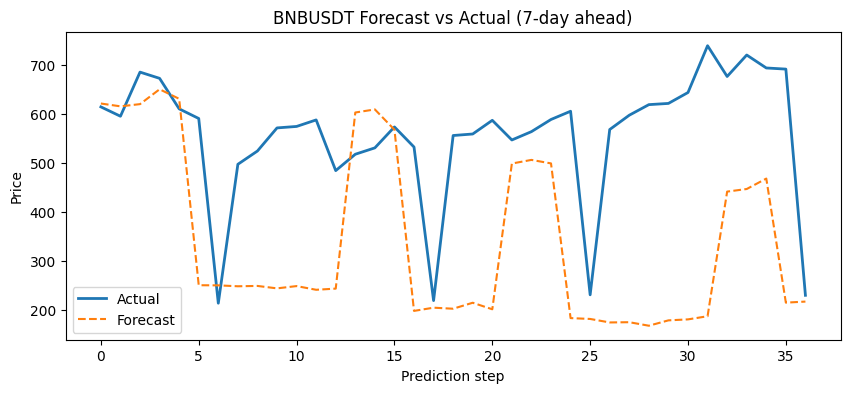


Training: BTCUSDT
BTCUSDT RMSE: 36116.49196802857


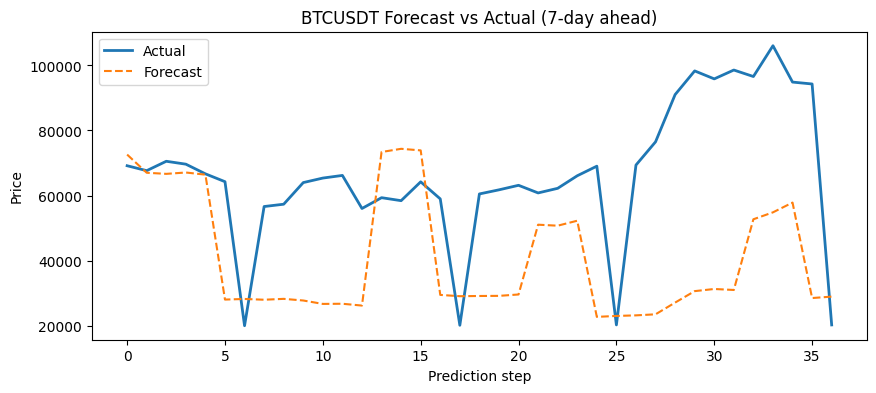


Training: ETHUSDT
ETHUSDT RMSE: 1269.4626584004602


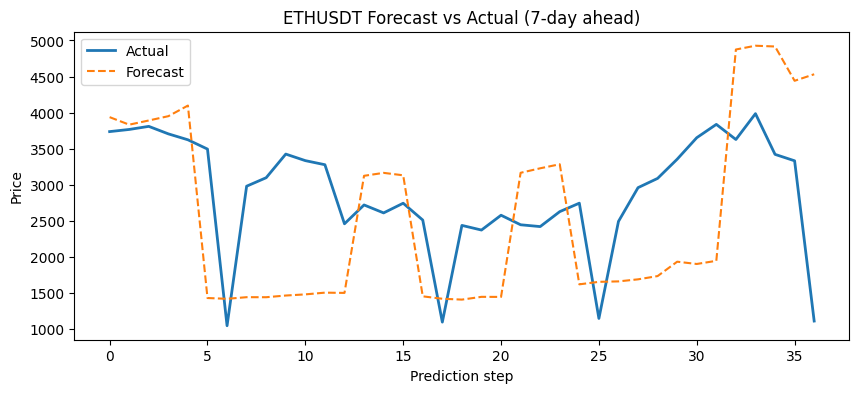


Training: SOLUSDT
SOLUSDT RMSE: 112.78144935719983


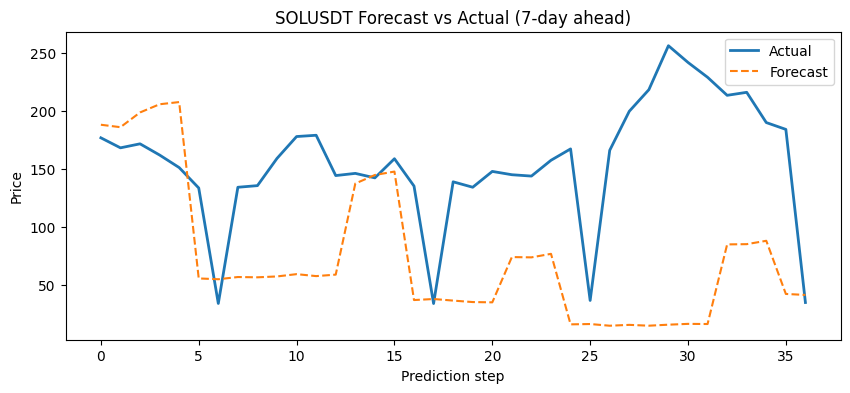


Training: TRXUSDT
TRXUSDT RMSE: 0.09454966702386039


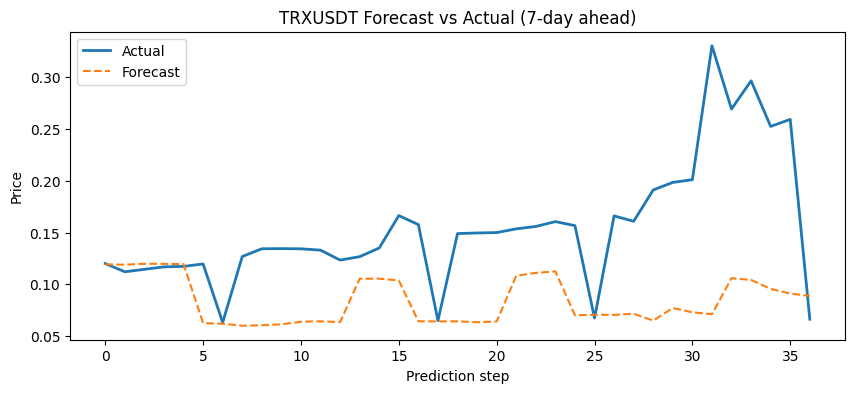


Training: XRPUSDT
XRPUSDT RMSE: 0.600473540026497


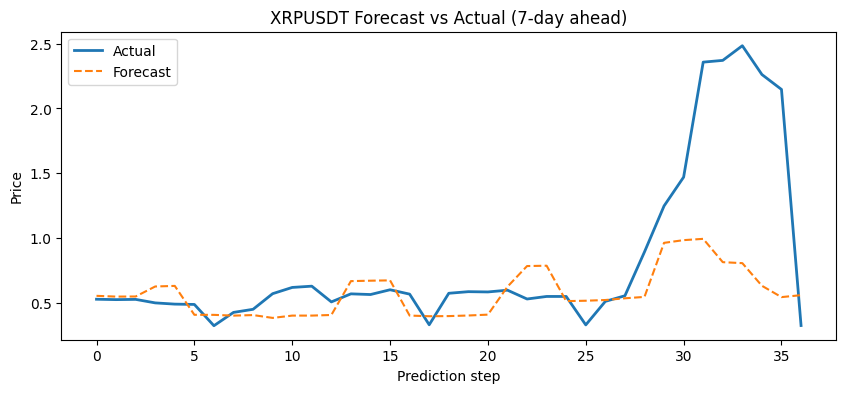

,coin,actual,forecast,returns_predicted
0,ADAUSDT,0.4835,0.482676,-0.001705
1,ADAUSDT,0.4512,0.497078,0.029401
2,ADAUSDT,0.4615,0.514253,0.033968
3,ADAUSDT,0.4442,0.512066,-0.004262
4,ADAUSDT,0.4168,0.513821,0.003421
...,...,...,...,...
32,XRPUSDT,2.3709,0.812999,-0.200086
33,XRPUSDT,2.4841,0.805393,-0.009400
34,XRPUSDT,2.2617,0.630641,-0.244593
35,XRPUSDT,2.1466,0.543172,-0.149311



RMSE Summary


,RMSE,Mean_Actual_Price,NRMSE_Percent
TRXUSDT,0.094550,0.155034,0.609866
ADAUSDT,0.232146,0.516959,0.449060
XRPUSDT,0.600474,0.813641,0.738008
SOLUSDT,112.781449,155.928108,0.723291
BCHUSDT,197.013967,372.651351,0.528682
BNBUSDT,285.736005,558.116486,0.511965
ETHUSDT,1269.462658,2895.692973,0.438397
BTCUSDT,36116.491968,66489.435946,0.543191


In [4]:
import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"

HORIZON = 7
N_LAGS = 14

results = {}
all_tables = []

# Lag funct
def create_lags(df, col, n_lags):

    for i in range(1, n_lags + 1):
        df[f"{col}_lag_{i}"] = df[col].shift(i)

    return df

files = os.listdir(data_folder)

print("Files detected:", len(files))
print(files[:10])

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv","")

    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)

    df.columns = ["index","close","time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")

    df = df.sort_values("time")
    # Returns
    df["return"] = np.log(df["close"] / df["close"].shift(1))


    # rolling vol
    df["vol_30"] = df["return"].rolling(30).std()
    df["vol_60"] = df["return"].rolling(60).std()

    df["target"] = df["return"].shift(-HORIZON)

    df = create_lags(df, "return", N_LAGS)
    df = create_lags(df, "vol_30", 10)
    df = create_lags(df, "vol_60", 10)

    df = df.dropna().reset_index(drop=True)

    X = df.drop(columns=["target","close","time"])
    y = df["target"]

    split = int(len(df) * 0.8)

    X_train = X.iloc[:split]
    X_test = X.iloc[split:]

    y_train = y.iloc[:split]
    y_test = y.iloc[split:]
    # Model
    model = xgb.XGBRegressor(

        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42

    )

    model.fit(X_train, y_train)

    preds_return = []
    actual_return = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]

        preds_return.append(pred)

        actual_return.append(y_test.iloc[i])


    actual_price = df["close"].iloc[split::7].values[:len(preds_return)]

    start_price = df["close"].iloc[split]

    preds_price = []

    price = start_price

    for r in preds_return:

        price = price * np.exp(r)

        preds_price.append(price)


    rmse = np.sqrt(mean_squared_error(actual_price, preds_price))
    mean_actual_price = np.mean(actual_price)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"{coin} RMSE:", rmse)



    table = pd.DataFrame({

        "coin": coin,
        "actual": actual_price,
        "forecast": preds_price,
        "returns_predicted": preds_return

    })

    all_tables.append(table)



    plt.figure(figsize=(10,4))

    plt.plot(actual_price, label="Actual", linewidth=2)
    plt.plot(preds_price, label="Forecast", linestyle="--")

    plt.title(f"{coin} Forecast vs Actual (7-day ahead)")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")

    plt.legend()

    plt.show()



final_table = pd.concat(all_tables)

display(final_table)

final_table.to_csv("12 XGB results/xgb_feature_forecasts.csv", index=False)


rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\nRMSE Summary")
display(rmse_table)
rmse_table.to_csv("12 XGB results/xgb_feature_rmses.csv", index=True)

In [5]:
np.save("Results New/XGBoost Features Forecast new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/xgb_feature_rmses.npy", rmse_table.values)
print("Saved .npy files for Model 2 (Features)")

Saved .npy files for Model 2 (Features)


## Model 3 — XGBoost Bayesian Optimised (BO)


Training: ADAUSDT


C:\Users\ameli\AppData\Local\Temp\ipykernel_32620\1499199729.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 23:12:18,575] A new study created in memory with name: no-name-f4d2be81-cf96-41ce-b6f7-cd4c77abd768


Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 1. Best value: 0.265752:   7%|▋         | 2/30 [00:00<00:07,  3.77it/s]

[I 2026-04-19 23:12:18,949] Trial 0 finished with value: 0.29550016688420705 and parameters: {'n_estimators': 493, 'max_depth': 10, 'learning_rate': 0.0844860892711149, 'subsample': 0.7353193450018701, 'colsample_bytree': 0.9823520430912795, 'gamma': 1.387456380098021, 'reg_alpha': 3.0933740610916742, 'reg_lambda': 4.166694719470042}. Best is trial 0 with value: 0.29550016688420705.
[I 2026-04-19 23:12:19,139] Trial 1 finished with value: 0.2657518020586239 and parameters: {'n_estimators': 238, 'max_depth': 3, 'learning_rate': 0.05820113347303107, 'subsample': 0.7616499224719928, 'colsample_bytree': 0.9853200382379217, 'gamma': 0.24317328992261633, 'reg_alpha': 4.454041082920527, 'reg_lambda': 2.9893993128872265}. Best is trial 1 with value: 0.2657518020586239.


...

[I 2026-04-19 23:12:26,226] Trial 27 finished with value: 0.21763104378505843 and parameters: {'n_estimators': 308, 'max_depth': 7, 'learning_rate': 0.04992678343833662, 'subsample': 0.8192875646456262, 'colsample_bytree': 0.6104583619447153, 'gamma': 0.008022296122949642, 'reg_alpha': 2.757451348562908, 'reg_lambda': 3.185616297705014}. Best is trial 23 with value: 0.19971894530505446.


Best trial: 23. Best value: 0.199719:  97%|█████████▋| 29/30 [00:07<00:00,  3.93it/s]

[I 2026-04-19 23:12:26,490] Trial 28 finished with value: 0.2512745657947414 and parameters: {'n_estimators': 332, 'max_depth': 8, 'learning_rate': 0.10860422088308108, 'subsample': 0.8631956286448644, 'colsample_bytree': 0.6635588511286483, 'gamma': 0.5648332002874152, 'reg_alpha': 1.442639031628335, 'reg_lambda': 4.126861357160926}. Best is trial 23 with value: 0.19971894530505446.


Best trial: 23. Best value: 0.199719: 100%|██████████| 30/30 [00:08<00:00,  3.64it/s]


[I 2026-04-19 23:12:26,806] Trial 29 finished with value: 0.2973699198992899 and parameters: {'n_estimators': 392, 'max_depth': 5, 'learning_rate': 0.08333906289473664, 'subsample': 0.7551627007373682, 'colsample_bytree': 0.5325096797130222, 'gamma': 1.249306102856622, 'reg_alpha': 3.3828449921706993, 'reg_lambda': 4.146603340255153}. Best is trial 23 with value: 0.19971894530505446.
Best params: {'n_estimators': 207, 'max_depth': 6, 'learning_rate': 0.046614443495784114, 'subsample': 0.8672886167168747, 'colsample_bytree': 0.5589340103343905, 'gamma': 0.013956761975005446, 'reg_alpha': 1.4885934017622247, 'reg_lambda': 1.752429549380614}

Top 10 Most Important Features:
   feature  importance
     close    0.258820
     lag_1    0.228639
     lag_4    0.180030
     lag_2    0.113358
     lag_3    0.103649
     lag_6    0.053444
     lag_5    0.006619
volatility    0.006593
log_return    0.006592
     lag_7    0.006415

ADAUSDT RMSE: 0.086454


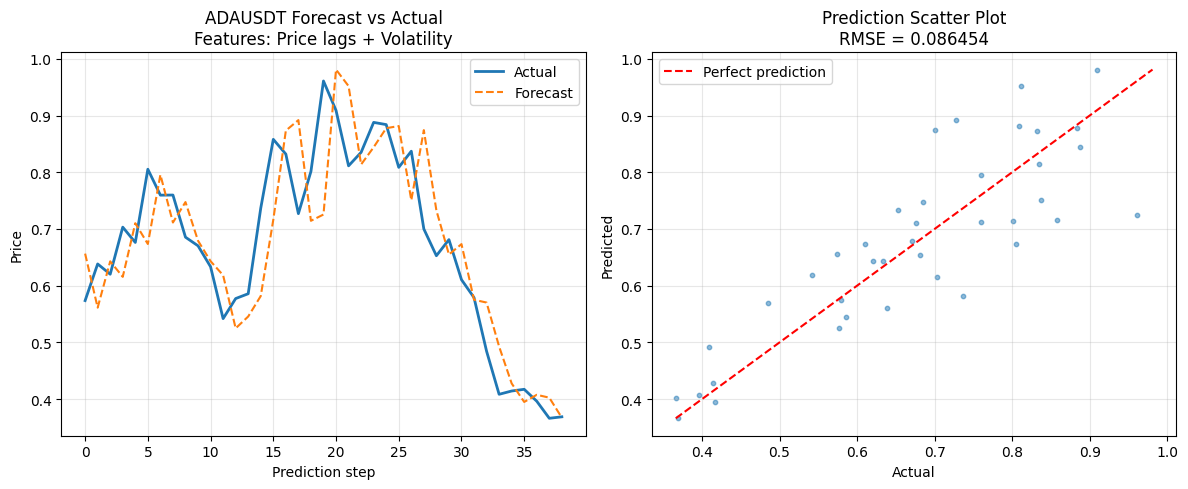

C:\Users\ameli\AppData\Local\Temp\ipykernel_32620\1499199729.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 23:12:28,524] A new study created in memory with name: no-name-c9aae2dd-7ae7-4440-9150-0e035d3285ad



Training: BCHUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 64.2895:   3%|▎         | 1/30 [00:00<00:19,  1.46it/s]

[I 2026-04-19 23:12:29,205] Trial 0 finished with value: 64.2895491920302 and parameters: {'n_estimators': 300, 'max_depth': 10, 'learning_rate': 0.12168933870490217, 'subsample': 0.96824324486926, 'colsample_bytree': 0.5459240524375499, 'gamma': 2.169250306705863, 'reg_alpha': 2.3014380176789153, 'reg_lambda': 2.008209049326404}. Best is trial 0 with value: 64.2895491920302.


Best trial: 1. Best value: 63.3221:   7%|▋         | 2/30 [00:01<00:18,  1.53it/s]

...

[I 2026-04-19 23:12:48,411] Trial 27 finished with value: 55.833054965236016 and parameters: {'n_estimators': 129, 'max_depth': 5, 'learning_rate': 0.019601793776156867, 'subsample': 0.7933983288683186, 'colsample_bytree': 0.7314367618856411, 'gamma': 2.9063707229941302, 'reg_alpha': 2.8665731175083105, 'reg_lambda': 1.4478901641400992}. Best is trial 6 with value: 51.40078832761387.


Best trial: 6. Best value: 51.4008:  97%|█████████▋| 29/30 [00:20<00:00,  1.75it/s]

[I 2026-04-19 23:12:49,086] Trial 28 finished with value: 63.73526380008851 and parameters: {'n_estimators': 219, 'max_depth': 7, 'learning_rate': 0.08576315180632786, 'subsample': 0.891972138425873, 'colsample_bytree': 0.7826614933425512, 'gamma': 3.2344442253096077, 'reg_alpha': 4.959911655156882, 'reg_lambda': 0.040236747281019}. Best is trial 6 with value: 51.40078832761387.


Best trial: 6. Best value: 51.4008: 100%|██████████| 30/30 [00:21<00:00,  1.41it/s]


[I 2026-04-19 23:12:49,855] Trial 29 finished with value: 59.15959341229048 and parameters: {'n_estimators': 313, 'max_depth': 6, 'learning_rate': 0.1770809531479219, 'subsample': 0.6041520365901524, 'colsample_bytree': 0.6530217569868044, 'gamma': 2.6397113259332574, 'reg_alpha': 4.205632394802576, 'reg_lambda': 2.11635379451422}. Best is trial 6 with value: 51.40078832761387.
Best params: {'n_estimators': 129, 'max_depth': 3, 'learning_rate': 0.018988628912117327, 'subsample': 0.639489624295889, 'colsample_bytree': 0.7500434361584343, 'gamma': 3.451008453151041, 'reg_alpha': 4.554415763112142, 'reg_lambda': 1.1500866016284856}

Top 10 Most Important Features:
feature  importance
  lag_1    0.266591
  close    0.236685
  lag_2    0.183223
  lag_3    0.060448
  lag_5    0.049962
  lag_4    0.042896
 lag_11    0.022739
 lag_12    0.021785
  lag_7    0.020840
  lag_6    0.019901

BCHUSDT RMSE: 74.703940


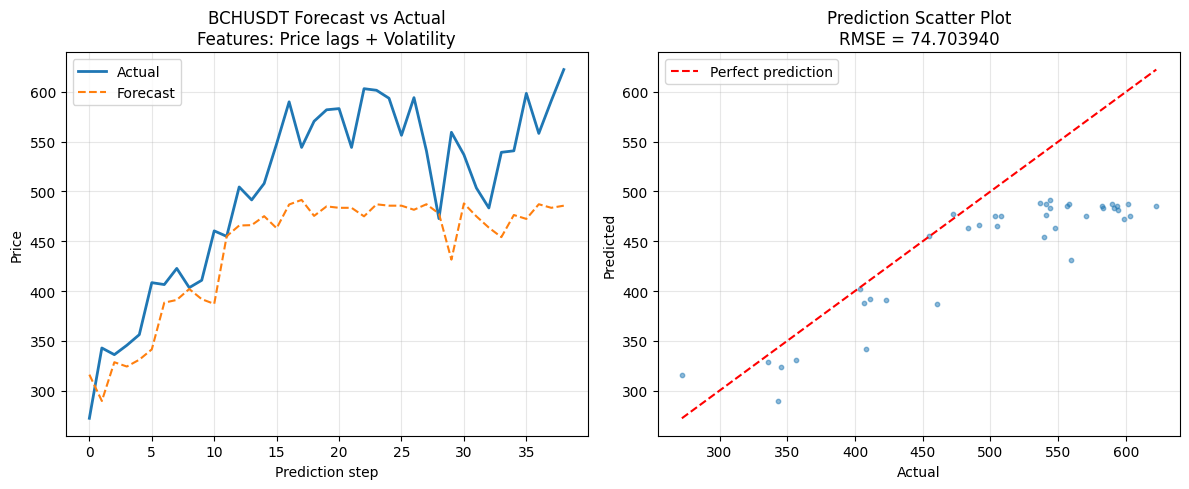

C:\Users\ameli\AppData\Local\Temp\ipykernel_32620\1499199729.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 23:12:51,487] A new study created in memory with name: no-name-fc13107f-987a-4924-82bc-11bb47c03ea9



Training: BNBUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 72.3516:   3%|▎         | 1/30 [00:01<00:36,  1.27s/it]

[I 2026-04-19 23:12:52,751] Trial 0 finished with value: 72.35158885191557 and parameters: {'n_estimators': 404, 'max_depth': 7, 'learning_rate': 0.13739074724870703, 'subsample': 0.5069754245356102, 'colsample_bytree': 0.7365400183197293, 'gamma': 1.5603307323007587, 'reg_alpha': 1.491176106852743, 'reg_lambda': 3.9282264789405374}. Best is trial 0 with value: 72.35158885191557.


Best trial: 0. Best value: 72.3516:   7%|▋         | 2/30 [00:02<00:29,  1.07s/it]

...

[I 2026-04-19 23:13:21,551] Trial 27 finished with value: 69.27910469441964 and parameters: {'n_estimators': 463, 'max_depth': 3, 'learning_rate': 0.05734659471378748, 'subsample': 0.8517748156691364, 'colsample_bytree': 0.5716527773865198, 'gamma': 3.6909169531046513, 'reg_alpha': 2.281600210055255, 'reg_lambda': 1.0187532968375137}. Best is trial 13 with value: 67.6774592251962.


Best trial: 13. Best value: 67.6775:  97%|█████████▋| 29/30 [00:31<00:01,  1.13s/it]

[I 2026-04-19 23:13:22,622] Trial 28 finished with value: 68.6945392203396 and parameters: {'n_estimators': 371, 'max_depth': 4, 'learning_rate': 0.10391825022303262, 'subsample': 0.9454695077751194, 'colsample_bytree': 0.6329103501224147, 'gamma': 2.811106086995178, 'reg_alpha': 3.08697700543584, 'reg_lambda': 1.7402148476069534}. Best is trial 13 with value: 67.6774592251962.


Best trial: 13. Best value: 67.6775: 100%|██████████| 30/30 [00:31<00:00,  1.06s/it]


[I 2026-04-19 23:13:23,433] Trial 29 finished with value: 69.11554552343432 and parameters: {'n_estimators': 409, 'max_depth': 6, 'learning_rate': 0.12708135415987942, 'subsample': 0.9973920626820437, 'colsample_bytree': 0.7413093191940252, 'gamma': 4.211444776687009, 'reg_alpha': 1.48111891277989, 'reg_lambda': 0.4019811913874887}. Best is trial 13 with value: 67.6774592251962.
Best params: {'n_estimators': 474, 'max_depth': 5, 'learning_rate': 0.10500284707097489, 'subsample': 0.9146864729908611, 'colsample_bytree': 0.6087587157716721, 'gamma': 3.0223340706706137, 'reg_alpha': 4.998380304729917, 'reg_lambda': 0.046323287651817216}

Top 10 Most Important Features:
   feature  importance
     lag_1    0.486321
     close    0.416661
     lag_2    0.037525
     lag_5    0.009411
     lag_4    0.007473
     lag_3    0.006953
    lag_13    0.005579
volatility    0.004660
    lag_10    0.003888
     lag_9    0.003662

BNBUSDT RMSE: 222.820609


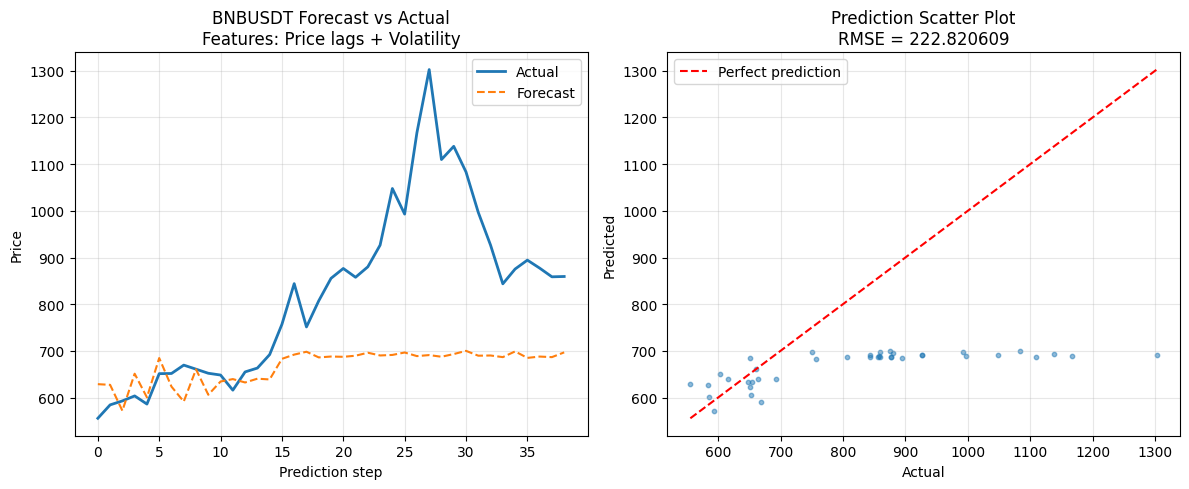


Training: BTCUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


C:\Users\ameli\AppData\Local\Temp\ipykernel_32620\1499199729.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 23:13:26,076] A new study created in memory with name: no-name-d13ece57-8100-47f5-a0b7-28cbc2e1eb73
Best trial: 0. Best value: 24876.7:   3%|▎         | 1/30 [00:03<01:39,  3.44s/it]

[I 2026-04-19 23:13:29,512] Trial 0 finished with value: 24876.703696388115 and parameters: {'n_estimators': 456, 'max_depth': 9, 'learning_rate': 0.10611354536559663, 'subsample': 0.7603491273169549, 'colsample_bytree': 0.9800908277206162, 'gamma': 2.321024626037929, 'reg_alpha': 0.12258513371835145, 'reg_lambda': 2.16041787335091}. Best is trial 0 with value: 24876.703696388115.


Best trial: 1. Best value: 22292.1:   7%|▋         | 2/30 [00:04<00:51,  1.86s/it]

[I 2026-04-19 23:13:30,259] Trial 1 finished with value: 22292.07252427771 and parameters: {'n_estimators': 450, 'max_depth': 3, 'learning_rate': 0.016493024312564594, 'subsample': 0.5703161831700165, 'colsample_bytree': 0.5782174234245746, 'gamma': 3.637200753637966, 'reg_alpha': 3.0119319726206, 'reg_lambda': 3.9789990473848134}. Best is trial 1 with value: 22292.07252427771.


...

[I 2026-04-19 23:14:04,721] Trial 27 finished with value: 22165.708903765957 and parameters: {'n_estimators': 471, 'max_depth': 3, 'learning_rate': 0.07782857459415835, 'subsample': 0.7747445085064943, 'colsample_bytree': 0.9093681721393528, 'gamma': 2.603747796211225, 'reg_alpha': 3.0174996875296163, 'reg_lambda': 2.9608267145387894}. Best is trial 12 with value: 21025.547835242854.


Best trial: 12. Best value: 21025.5:  97%|█████████▋| 29/30 [00:40<00:01,  1.13s/it]

[I 2026-04-19 23:14:06,292] Trial 28 finished with value: 21499.207116029338 and parameters: {'n_estimators': 389, 'max_depth': 6, 'learning_rate': 0.025693934094371727, 'subsample': 0.9954226242068716, 'colsample_bytree': 0.8335480132778998, 'gamma': 1.7596567500943472, 'reg_alpha': 2.331890934815994, 'reg_lambda': 0.0010679417408326897}. Best is trial 12 with value: 21025.547835242854.


Best trial: 12. Best value: 21025.5: 100%|██████████| 30/30 [00:42<00:00,  1.41s/it]


[I 2026-04-19 23:14:08,316] Trial 29 finished with value: 23152.241440282774 and parameters: {'n_estimators': 341, 'max_depth': 8, 'learning_rate': 0.021442287906245108, 'subsample': 0.9919303602718422, 'colsample_bytree': 0.7840150581348024, 'gamma': 1.7660671661851193, 'reg_alpha': 3.6870355001726853, 'reg_lambda': 0.02581056764161327}. Best is trial 12 with value: 21025.547835242854.
Best params: {'n_estimators': 497, 'max_depth': 3, 'learning_rate': 0.014275536485529386, 'subsample': 0.9611766023319284, 'colsample_bytree': 0.8608903334532667, 'gamma': 3.288530605281241, 'reg_alpha': 1.7464871785535216, 'reg_lambda': 0.5903572588946484}

Top 10 Most Important Features:
feature  importance
  lag_4    0.308419
  lag_5    0.290127
  lag_9    0.097236
  close    0.086621
  lag_1    0.081435
 lag_10    0.031184
  lag_7    0.028153
  lag_8    0.023245
  lag_6    0.019797
 lag_11    0.012133

BTCUSDT RMSE: 13315.027943


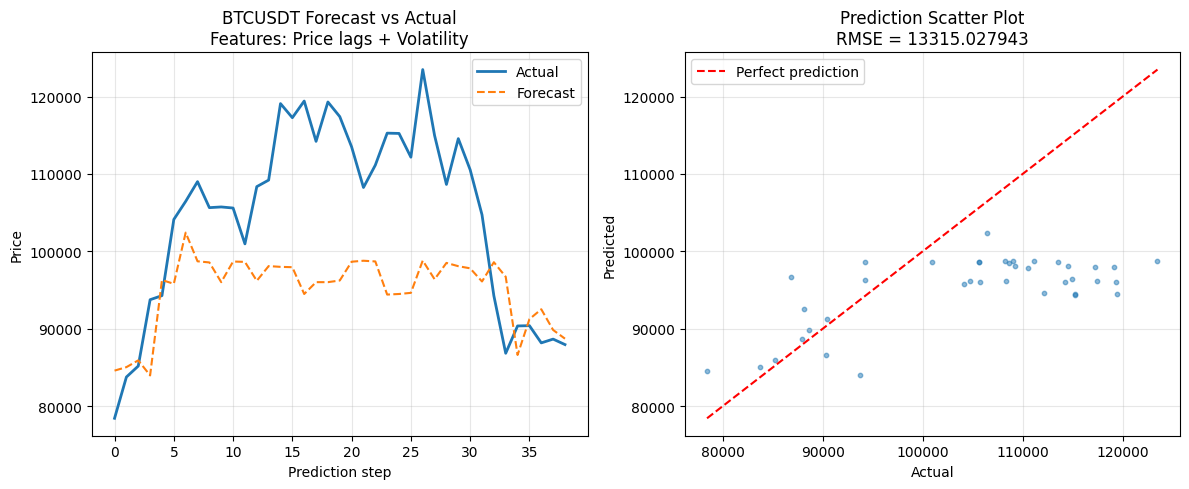


Training: ETHUSDT


C:\Users\ameli\AppData\Local\Temp\ipykernel_32620\1499199729.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 23:14:10,226] A new study created in memory with name: no-name-3f63e3ae-88cf-48d4-bd4c-750eb7783f05


Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 314.674:   3%|▎         | 1/30 [00:00<00:09,  3.17it/s]

[I 2026-04-19 23:14:10,538] Trial 0 finished with value: 314.6744047279922 and parameters: {'n_estimators': 248, 'max_depth': 3, 'learning_rate': 0.09573499250277635, 'subsample': 0.797293216342913, 'colsample_bytree': 0.5700976722033211, 'gamma': 3.237388630025213, 'reg_alpha': 3.449930558387277, 'reg_lambda': 0.33462963717311167}. Best is trial 0 with value: 314.6744047279922.


...

[I 2026-04-19 23:14:31,575] Trial 27 finished with value: 302.1039003391169 and parameters: {'n_estimators': 193, 'max_depth': 4, 'learning_rate': 0.013568829557787376, 'subsample': 0.5794134114814151, 'colsample_bytree': 0.8091123648820547, 'gamma': 3.0384997106441682, 'reg_alpha': 3.658248747203744, 'reg_lambda': 4.615585062802965}. Best is trial 25 with value: 289.7827286545924.


Best trial: 25. Best value: 289.783:  97%|█████████▋| 29/30 [00:22<00:00,  1.51it/s]

[I 2026-04-19 23:14:32,598] Trial 28 finished with value: 313.6966357420178 and parameters: {'n_estimators': 137, 'max_depth': 10, 'learning_rate': 0.08532237128606772, 'subsample': 0.6945083057919251, 'colsample_bytree': 0.8978594152727416, 'gamma': 2.2452388089523803, 'reg_alpha': 3.9132065973783945, 'reg_lambda': 0.9165017062067771}. Best is trial 25 with value: 289.7827286545924.


Best trial: 25. Best value: 289.783: 100%|██████████| 30/30 [00:22<00:00,  1.31it/s]


[I 2026-04-19 23:14:33,038] Trial 29 finished with value: 300.4115589225254 and parameters: {'n_estimators': 278, 'max_depth': 3, 'learning_rate': 0.1047418430798213, 'subsample': 0.5651171694530952, 'colsample_bytree': 0.8497858401857267, 'gamma': 3.1701293078821924, 'reg_alpha': 4.092308263821007, 'reg_lambda': 0.5228705279469092}. Best is trial 25 with value: 289.7827286545924.
Best params: {'n_estimators': 183, 'max_depth': 3, 'learning_rate': 0.04732708797031698, 'subsample': 0.5600101989784151, 'colsample_bytree': 0.866661309023517, 'gamma': 2.8855701010100216, 'reg_alpha': 3.7142070071697146, 'reg_lambda': 1.263069375115898}

Top 10 Most Important Features:
feature  importance
  lag_1    0.344238
  close    0.245062
  lag_2    0.226034
  lag_3    0.077024
  lag_4    0.014598
  lag_7    0.012059
  lag_6    0.009542
 lag_11    0.008947
 lag_13    0.008021
 lag_14    0.007992

ETHUSDT RMSE: 525.147095


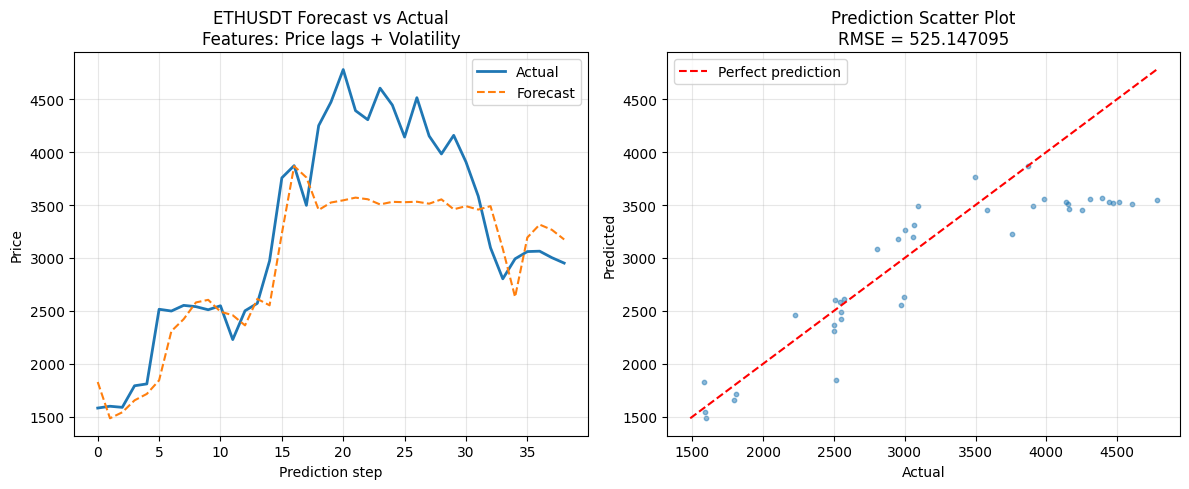


Training: SOLUSDT


C:\Users\ameli\AppData\Local\Temp\ipykernel_32620\1499199729.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 23:14:34,531] A new study created in memory with name: no-name-702f48e1-480a-4ce7-89cd-32d47dc90810


Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 37.0365:   3%|▎         | 1/30 [00:00<00:22,  1.29it/s]

[I 2026-04-19 23:14:35,303] Trial 0 finished with value: 37.036464388963545 and parameters: {'n_estimators': 446, 'max_depth': 10, 'learning_rate': 0.09370261347773952, 'subsample': 0.5092031572288365, 'colsample_bytree': 0.8083634059504843, 'gamma': 3.177273828772443, 'reg_alpha': 3.0749313798177322, 'reg_lambda': 0.20641152491239656}. Best is trial 0 with value: 37.036464388963545.


...

[I 2026-04-19 23:14:49,530] Trial 27 finished with value: 36.25761549571548 and parameters: {'n_estimators': 284, 'max_depth': 3, 'learning_rate': 0.06046654269125498, 'subsample': 0.9997063734239093, 'colsample_bytree': 0.5475187856801287, 'gamma': 2.404012753303243, 'reg_alpha': 0.44006469992412356, 'reg_lambda': 3.5473736826359383}. Best is trial 12 with value: 34.92564826016053.


Best trial: 12. Best value: 34.9256:  97%|█████████▋| 29/30 [00:15<00:00,  2.47it/s]

[I 2026-04-19 23:14:49,881] Trial 28 finished with value: 37.451495592142685 and parameters: {'n_estimators': 135, 'max_depth': 5, 'learning_rate': 0.03660743465224258, 'subsample': 0.9221941161205272, 'colsample_bytree': 0.8527353559605912, 'gamma': 4.614563802523326, 'reg_alpha': 4.647160311618932, 'reg_lambda': 1.5672151547770334}. Best is trial 12 with value: 34.92564826016053.


Best trial: 12. Best value: 34.9256: 100%|██████████| 30/30 [00:16<00:00,  1.86it/s]


[I 2026-04-19 23:14:50,680] Trial 29 finished with value: 39.029002455507616 and parameters: {'n_estimators': 483, 'max_depth': 10, 'learning_rate': 0.09572717858475036, 'subsample': 0.7976759946441414, 'colsample_bytree': 0.7028319443385534, 'gamma': 3.2079877846898706, 'reg_alpha': 1.552759879042229, 'reg_lambda': 4.1838955561976965}. Best is trial 12 with value: 34.92564826016053.
Best params: {'n_estimators': 364, 'max_depth': 3, 'learning_rate': 0.04025827790283778, 'subsample': 0.9862047672364135, 'colsample_bytree': 0.7075497164571641, 'gamma': 3.844333990112542, 'reg_alpha': 0.3394340378441649, 'reg_lambda': 3.4605080710141567}

Top 10 Most Important Features:
feature  importance
  lag_1    0.338276
  close    0.338075
  lag_2    0.129824
  lag_5    0.044857
  lag_9    0.040774
  lag_8    0.027269
  lag_3    0.016614
  lag_7    0.013914
 lag_10    0.010497
 lag_11    0.008708

SOLUSDT RMSE: 18.591004


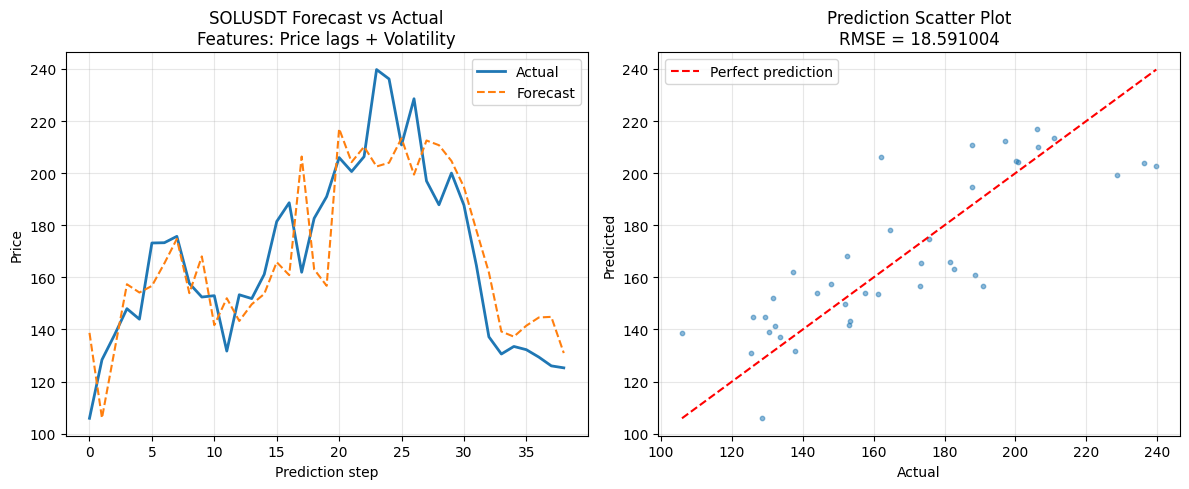


Training: TRXUSDT


C:\Users\ameli\AppData\Local\Temp\ipykernel_32620\1499199729.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 23:14:52,430] A new study created in memory with name: no-name-7fe2df97-2e45-4afa-8a9a-aa8a49b4a89c


Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 0.12603:   3%|▎         | 1/30 [00:00<00:09,  3.05it/s]

[I 2026-04-19 23:14:52,754] Trial 0 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 492, 'max_depth': 7, 'learning_rate': 0.18820367030228993, 'subsample': 0.8115952052654762, 'colsample_bytree': 0.9994971516749727, 'gamma': 3.290008764407703, 'reg_alpha': 2.729667012206594, 'reg_lambda': 0.479412437319377}. Best is trial 0 with value: 0.12602966170678476.
[I 2026-04-19 23:14:52,952] Trial 1 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 259, 'max_depth': 6, 'learning_rate': 0.12095223512922501, 'subsample': 0.5386655324806013, 'colsample_bytree': 0.8683765928861096, 'gamma': 2.968838837332129, 'reg_alpha': 4.539516599874106, 'reg_lambda': 1.7174660914124829}. Best is trial 0 with value: 0.12602966170678476.


...

[I 2026-04-19 23:14:57,678] Trial 24 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 141, 'max_depth': 8, 'learning_rate': 0.17305255783411808, 'subsample': 0.6947711496305675, 'colsample_bytree': 0.9625232585190432, 'gamma': 0.979095736275842, 'reg_alpha': 3.048615627083335, 'reg_lambda': 2.8069989147584757}. Best is trial 22 with value: 0.10721046524127072.
[I 2026-04-19 23:14:57,834] Trial 25 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 143, 'max_depth': 8, 'learning_rate': 0.14182864745181487, 'subsample': 0.7141218612193688, 'colsample_bytree': 0.9379657760320519, 'gamma': 0.6984219579036138, 'reg_alpha': 2.233387749726252, 'reg_lambda': 2.1141990055112885}. Best is trial 22 with value: 0.10721046524127072.


Best trial: 22. Best value: 0.10721:  93%|█████████▎| 28/30 [00:05<00:00,  5.76it/s]

[I 2026-04-19 23:14:58,052] Trial 26 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 230, 'max_depth': 8, 'learning_rate': 0.12090276660720978, 'subsample': 0.6420877042129415, 'colsample_bytree': 0.9030762830329385, 'gamma': 1.5256774611878272, 'reg_alpha': 1.7203641051600946, 'reg_lambda': 2.90619337988188}. Best is trial 22 with value: 0.10721046524127072.
[I 2026-04-19 23:14:58,194] Trial 27 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 101, 'max_depth': 9, 'learning_rate': 0.17286687763249634, 'subsample': 0.8616836726092555, 'colsample_bytree': 0.9629654918184969, 'gamma': 0.45519372612823195, 'reg_alpha': 2.2571523355594567, 'reg_lambda': 3.7467802040547395}. Best is trial 22 with value: 0.10721046524127072.


Best trial: 22. Best value: 0.10721: 100%|██████████| 30/30 [00:06<00:00,  4.87it/s]


[I 2026-04-19 23:14:58,430] Trial 28 finished with value: 0.11778465550206502 and parameters: {'n_estimators': 270, 'max_depth': 7, 'learning_rate': 0.06931205530895015, 'subsample': 0.7609788168565579, 'colsample_bytree': 0.9007673098533002, 'gamma': 0.008566018872160006, 'reg_alpha': 3.7306426859408104, 'reg_lambda': 4.37215821741138}. Best is trial 22 with value: 0.10721046524127072.
[I 2026-04-19 23:14:58,587] Trial 29 finished with value: 0.12602966170678476 and parameters: {'n_estimators': 144, 'max_depth': 7, 'learning_rate': 0.18174877139378673, 'subsample': 0.6500331161187376, 'colsample_bytree': 0.9708752871211119, 'gamma': 4.909927219223005, 'reg_alpha': 2.7857971238160717, 'reg_lambda': 0.0033700774191522953}. Best is trial 22 with value: 0.10721046524127072.
Best params: {'n_estimators': 147, 'max_depth': 8, 'learning_rate': 0.17663900345781602, 'subsample': 0.8697421654791141, 'colsample_bytree': 0.9386109710490209, 'gamma': 0.030921496124031084, 'reg_alpha': 0.7950543192

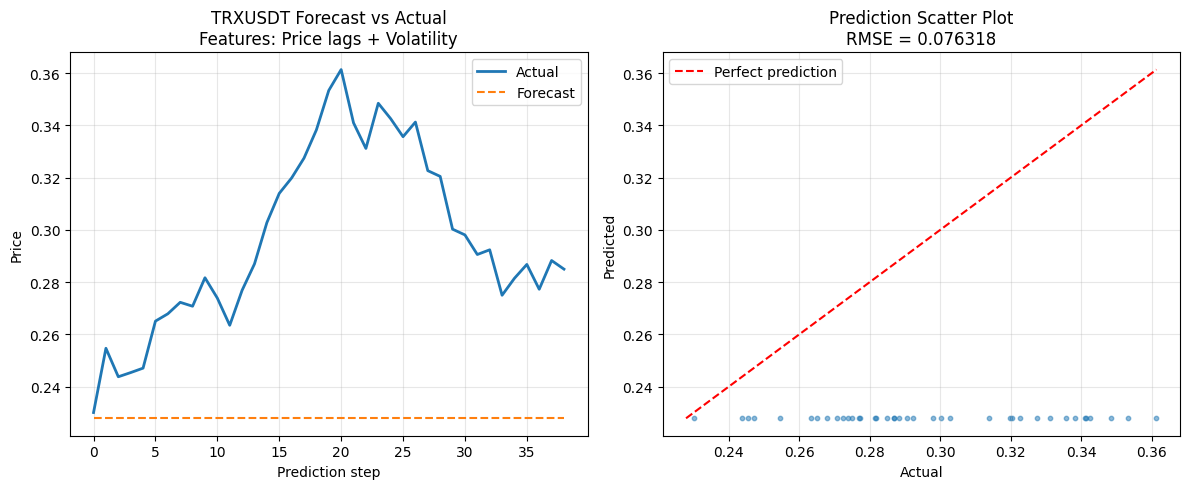

C:\Users\ameli\AppData\Local\Temp\ipykernel_32620\1499199729.py:48: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["time"] = pd.to_datetime(df["time"], errors="coerce")
[I 2026-04-19 23:14:59,936] A new study created in memory with name: no-name-30b05d6c-1c23-42e0-aa98-ff7fea3119b8



Training: XRPUSDT
Features used (17 total):
  - Price lags: 14 features
  - Volatility features: 1 features
  - Other features: 2 features
Training samples: 810, Validation samples: 270, Test samples: 270


Best trial: 0. Best value: 1.38531:   3%|▎         | 1/30 [00:00<00:08,  3.31it/s]

[I 2026-04-19 23:15:00,236] Trial 0 finished with value: 1.3853101632519706 and parameters: {'n_estimators': 428, 'max_depth': 5, 'learning_rate': 0.19703690903601395, 'subsample': 0.9547074912493612, 'colsample_bytree': 0.8426124132129778, 'gamma': 2.0244920466267304, 'reg_alpha': 4.498608537709192, 'reg_lambda': 4.441130369051944}. Best is trial 0 with value: 1.3853101632519706.


Best trial: 1. Best value: 1.3783:   7%|▋         | 2/30 [00:00<00:07,  3.99it/s] 

...

[I 2026-04-19 23:15:06,479] Trial 25 finished with value: 1.3553365377751059 and parameters: {'n_estimators': 201, 'max_depth': 3, 'learning_rate': 0.018935302241997354, 'subsample': 0.8039671281066887, 'colsample_bytree': 0.5248185511296832, 'gamma': 0.6528702980136721, 'reg_alpha': 1.9464467166477668, 'reg_lambda': 3.5342798605446264}. Best is trial 13 with value: 1.2846752473386704.
[I 2026-04-19 23:15:06,628] Trial 26 finished with value: 1.3657215489406793 and parameters: {'n_estimators': 134, 'max_depth': 7, 'learning_rate': 0.11898314277565629, 'subsample': 0.7008437746150895, 'colsample_bytree': 0.797783165469356, 'gamma': 1.3992749889095963, 'reg_alpha': 0.5123591503845439, 'reg_lambda': 0.6538226516861116}. Best is trial 13 with value: 1.2846752473386704.


Best trial: 13. Best value: 1.28468:  93%|█████████▎| 28/30 [00:06<00:00,  4.55it/s]

[I 2026-04-19 23:15:06,890] Trial 27 finished with value: 1.3450711939540585 and parameters: {'n_estimators': 293, 'max_depth': 9, 'learning_rate': 0.09377081444867316, 'subsample': 0.7611069735236642, 'colsample_bytree': 0.7320079215850417, 'gamma': 0.6199993619245492, 'reg_alpha': 0.4676192172429661, 'reg_lambda': 2.5522251228996793}. Best is trial 13 with value: 1.2846752473386704.


Best trial: 13. Best value: 1.28468: 100%|██████████| 30/30 [00:07<00:00,  4.01it/s]


[I 2026-04-19 23:15:07,222] Trial 28 finished with value: 1.360465867238441 and parameters: {'n_estimators': 388, 'max_depth': 6, 'learning_rate': 0.15017267674568713, 'subsample': 0.8069888920684113, 'colsample_bytree': 0.6590995653071251, 'gamma': 1.1311496219768349, 'reg_alpha': 1.1189498547142085, 'reg_lambda': 1.3107847044970555}. Best is trial 13 with value: 1.2846752473386704.
[I 2026-04-19 23:15:07,410] Trial 29 finished with value: 1.379760107977864 and parameters: {'n_estimators': 203, 'max_depth': 5, 'learning_rate': 0.12677583853733254, 'subsample': 0.8562963345987801, 'colsample_bytree': 0.5850061944654541, 'gamma': 2.3217416133609294, 'reg_alpha': 1.7012782918067122, 'reg_lambda': 1.9376665049570865}. Best is trial 13 with value: 1.2846752473386704.
Best params: {'n_estimators': 276, 'max_depth': 6, 'learning_rate': 0.1461969009098758, 'subsample': 0.794250524679371, 'colsample_bytree': 0.5000145614584753, 'gamma': 0.05194550487463319, 'reg_alpha': 0.03722623673739016, 'r

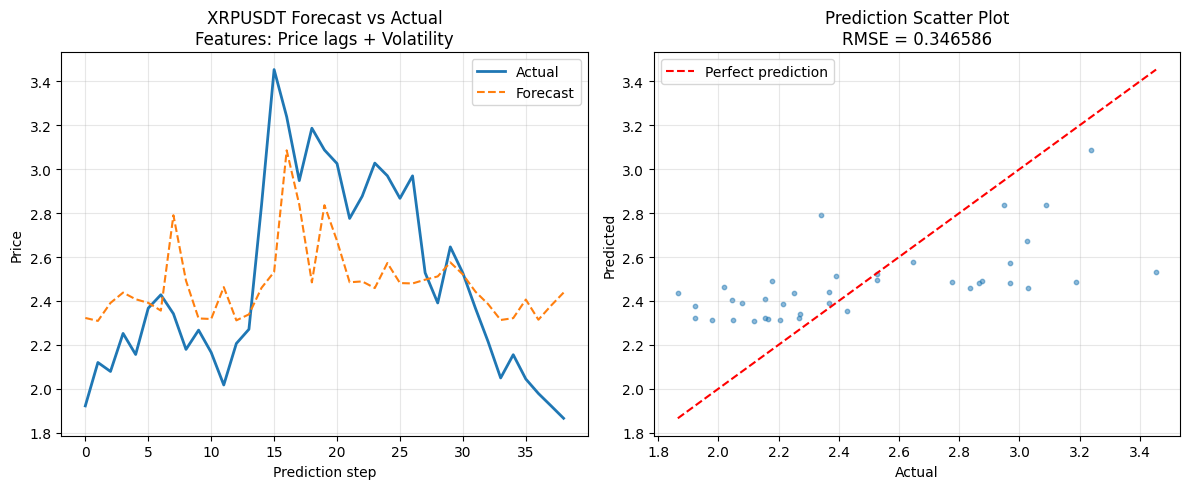


RMSE SUMMARY
                 RMSE  Mean_Actual_Price  NRMSE_Percent
TRXUSDT      0.076318           0.296315       0.257558
ADAUSDT      0.086454           0.671769       0.128696
XRPUSDT      0.346586           2.480085       0.139747
SOLUSDT     18.591004         167.505128       0.110988
BCHUSDT     74.703940         502.102564       0.148782
BNBUSDT    222.820609         820.774615       0.271476
ETHUSDT    525.147095        3219.931282       0.163093
BTCUSDT  13315.027943      104518.519744       0.127394

SUMMARY STATISTICS
Mean RMSE: 1769.599994
Median RMSE: 46.647472
Mean NRMSE (%): 0.1685%
Median NRMSE (%): 0.1443%
Best RMSE: 0.076318 (TRXUSDT)
Worst RMSE: 13315.027943 (BTCUSDT)


In [6]:

import pandas as pd
import numpy as np
import xgboost as xgb
import os
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import optuna

data_folder = "klines csv data/prices_cleaned"
HORIZON = 7
N_LAGS = 14
VOLATILITY_WINDOW = 7

results = {}
all_tables = []

def create_features(df):
    df = df.copy()

    # log return
    df["log_return"] = np.log(df["close"] / df["close"].shift(1))

    # volatility
    df["volatility"] = df["log_return"].rolling(window=VOLATILITY_WINDOW).std()

    # lagged prices only
    for i in range(1, N_LAGS + 1):
        df[f"lag_{i}"] = df["close"].shift(i)

    return df

files = os.listdir(data_folder)

for file in files:

    if file.startswith("."):
        continue

    coin = file.replace(".csv", "")
    print("\nTraining:", coin)

    path = os.path.join(data_folder, file)

    df = pd.read_csv(path, header=None)
    df.columns = ["index", "close", "time"]

    df["close"] = pd.to_numeric(df["close"], errors="coerce")
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df = df.sort_values("time")
    df = df[["close"]]

    # tiny coins
    tiny_price = df["close"].median() < 0.01

    if tiny_price:
        print("Tiny price detected → using log price")
        df["close"] = np.log(df["close"])

    # add features: price lags + volatility only
    df = create_features(df)

    # target = future closing price HORIZON steps ahead
    df["target"] = df["close"].shift(-HORIZON)

    # drop rows with NaN
    df = df.dropna().reset_index(drop=True)

    # exclude target, keep everything else
    X = df.drop(columns=["target"])
    y = df["target"]

    split1 = int(len(df) * 0.6)
    split2 = int(len(df) * 0.8)

    X_train = X.iloc[:split1]
    X_val   = X.iloc[split1:split2]
    X_test  = X.iloc[split2:]

    y_train = y.iloc[:split1]
    y_val   = y.iloc[split1:split2]
    y_test  = y.iloc[split2:]

    print(f"Features used ({len(X.columns)} total):")
    price_lags = [col for col in X.columns if col.startswith("lag_")]
    vol_features = [col for col in X.columns if "vol" in col.lower()]
    other_features = [col for col in X.columns if col not in price_lags and col not in vol_features]

    print(f"  - Price lags: {len(price_lags)} features")
    print(f"  - Volatility features: {len(vol_features)} features")
    print(f"  - Other features: {len(other_features)} features")
    print(f"Training samples: {len(X_train)}, Validation samples: {len(X_val)}, Test samples: {len(X_test)}")

    # Bayesian Optimisation
    def objective(trial):

        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 500),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2),
            "subsample": trial.suggest_float("subsample", 0.5, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0, 5),
            "reg_lambda": trial.suggest_float("reg_lambda", 0, 5),
            "objective": "reg:squarederror",
            "random_state": 42
        }

        model = xgb.XGBRegressor(**params)
        model.fit(X_train, y_train, verbose=False)

        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        return rmse

    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=30, show_progress_bar=True)

    best_params = study.best_params
    print("Best params:", best_params)

    model = xgb.XGBRegressor(
        **best_params,
        objective="reg:squarederror",
        random_state=42
    )

    X_train_full = pd.concat([X_train, X_val], axis=0)
    y_train_full = pd.concat([y_train, y_val], axis=0)

    model.fit(X_train_full, y_train_full, verbose=False)

    feature_importance = pd.DataFrame({
        "feature": X.columns,
        "importance": model.feature_importances_
    }).sort_values("importance", ascending=False)

    print("\nTop 10 Most Important Features:")
    print(feature_importance.head(10).to_string(index=False))

    preds = []
    actual = []
    current_prices = []

    for i in range(0, len(X_test), 7):

        if i >= len(X_test):
            break

        pred = model.predict(X_test.iloc[i:i+1])[0]
        current_price_raw = X_test.iloc[i]['close']

        if tiny_price:
            preds.append(np.exp(pred))
            actual.append(np.exp(y_test.iloc[i]))
            current_prices.append(np.exp(current_price_raw))
        else:
            preds.append(pred)
            actual.append(y_test.iloc[i])
            current_prices.append(current_price_raw)

    preds = np.array(preds)
    actual = np.array(actual)
    current_prices = np.array(current_prices)

    rmse = np.sqrt(mean_squared_error(actual, preds))
    mean_actual_price = np.mean(actual)
    nrmse_percent = (rmse / mean_actual_price)

    results[coin] = {
        "RMSE": rmse,
        "Mean_Actual_Price": mean_actual_price,
        "NRMSE_Percent": nrmse_percent
    }

    print(f"\n{coin} RMSE: {rmse:.6f}")

    # returns_predicted = (forecast - current_price) / current_price
    # gives a true forward-looking expected return signal for CMVO
    table = pd.DataFrame({
        "coin": coin,
        "actual": actual,
        "forecast": preds,
        "returns_predicted": (preds - current_prices) / current_prices
    })

    all_tables.append(table)

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(actual, label="Actual", linewidth=2)
    plt.plot(preds, label="Forecast", linestyle="--")
    plt.title(f"{coin} Forecast vs Actual\nFeatures: Price lags + Volatility")
    plt.xlabel("Prediction step")
    plt.ylabel("Price")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.subplot(1, 2, 2)
    plt.scatter(actual, preds, alpha=0.5, s=10)
    min_val = min(min(actual), min(preds))
    max_val = max(max(actual), max(preds))
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', label="Perfect prediction")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.title(f"Prediction Scatter Plot\nRMSE = {rmse:.6f}")
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

final_table = pd.concat(all_tables, ignore_index=True)
final_table.to_csv("12 XGB results/xgboost_forecasts_BO_price_vol.csv", index=False)

rmse_table = pd.DataFrame.from_dict(results, orient="index")
rmse_table = rmse_table.sort_values("RMSE")

print("\n" + "="*60)
print("RMSE SUMMARY")
print("="*60)
print(rmse_table)
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Mean RMSE: {rmse_table['RMSE'].mean():.6f}")
print(f"Median RMSE: {rmse_table['RMSE'].median():.6f}")
print(f"Mean NRMSE (%): {rmse_table['NRMSE_Percent'].mean():.4f}%")
print(f"Median NRMSE (%): {rmse_table['NRMSE_Percent'].median():.4f}%")
print(f"Best RMSE: {rmse_table['RMSE'].min():.6f} ({rmse_table.index[rmse_table['RMSE'].argmin()]})")
print(f"Worst RMSE: {rmse_table['RMSE'].max():.6f} ({rmse_table.index[rmse_table['RMSE'].argmax()]})")

rmse_table.to_csv("12 XGB results/xgboost_rmse_summary_BO_price_vol.csv")


In [7]:
np.save("Results New/Features and BO new return.npy", final_table[["coin", "actual", "forecast", "returns_predicted"]].values)
np.save("12 XGB results/xgboost_rmse_summary_BO_price_vol.npy", rmse_table.values)
print("Saved .npy files for Model 3 (BO)")

Saved .npy files for Model 3 (BO)
